# **Part 07**
# **Electric Potential and Nernst–Planck Ion Migration**

## **Objective**

The objective of Part 7 is to extend the electrode-driven reaction–diffusion model developed in Part 6 by including electric potential and charge-dependent ion migration.

In Part 6, hydrogen and hydroxide ions moved only through diffusion. In Part 7, their transport is controlled by:

1. Diffusion caused by concentration gradients;
2. Migration caused by the electric field;
3. Electrode injection;
4. Hydrogen–hydroxide neutralization.

The electric potential is calculated first. It is then used to determine the electric field and the migration velocity of each ion. Finally, the coupled Nernst–Planck reaction–diffusion equations are solved using the finite element method.

---

## **Importance**

Charged particles do not move only because of concentration differences. They also respond to an applied electric field.

Hydrogen ions have a positive charge, while hydroxide ions have a negative charge. Therefore, they migrate in opposite directions under the same electric field.

Including ion migration is necessary because it:

* makes the model more representative of electrochemical transport;
* distinguishes neutral diffusion from charged-species transport;
* connects electric potential with ion concentration;
* introduces the Nernst–Planck transport equation;
* allows opposite migration of positive and negative ions;
* provides a closer connection with the COMSOL electrochemical model;
* prepares the framework for more realistic electrochemical simulations.

---

## **Computational Domain**

The simulation is performed on the unit-square domain

$$
\Omega=[0,1]\times[0,1]\ \mathrm{cm}^2.
$$

The mesh contains

$$
N_x=N_y=12
$$

subdivisions in each coordinate direction.

Therefore, the number of nodes is

$$
N_{\mathrm{nodes}}=(N_x+1)(N_y+1)=169,
$$

and the number of triangular elements is

$$
N_{\mathrm{elements}}=2N_xN_y=288.
$$

---

## **Electric-Potential Equation**

The electric potential is represented by

$$
\phi(x,y).
$$

Assuming a uniform electrical conductivity and no internal electrical source, the potential satisfies Laplace’s equation:

$$
\nabla^2\phi=0
\qquad \text{in } \Omega.
$$

More generally, electric-current conservation can be written as

$$
\nabla\cdot(\sigma\nabla\phi)=0,
$$

where $\sigma$ is the electrical conductivity.

Because the code assumes a constant conductivity, the equation reduces to

$$
\nabla^2\phi=0.
$$

---

## **Electric-Potential Boundary Conditions**

The anode is placed on the left boundary and assigned the potential

$$
\phi=0.10\ \mathrm{V}
\qquad \text{at } x=0.
$$

The cathode is placed on the right boundary and assigned the potential

$$
\phi=0\ \mathrm{V}
\qquad \text{at } x=1.
$$

The applied potential difference is therefore

$$
\Delta\phi=\phi_{\mathrm{anode}}-\phi_{\mathrm{cathode}}=0.10\ \mathrm{V}.
$$

The top and bottom boundaries are electrically insulated:

$$
\nabla\phi\cdot\mathbf{n}=0.
$$

Here, $\mathbf{n}$ is the outward unit-normal vector.

---

## **Exact Electric-Potential Solution**

Because the domain is rectangular and the potential values are constant on the left and right boundaries, the exact solution is linear in the $x$-direction:

$$
\phi_{\mathrm{exact}}(x)=\phi_{\mathrm{anode}}+\frac{\phi_{\mathrm{cathode}}-\phi_{\mathrm{anode}}}{L_x}x.
$$

For the current values,

$$
\phi_{\mathrm{exact}}(x)=0.10(1-x).
$$

The numerical potential error is calculated using

$$
E_{\phi}=\max_i\left|\phi_i-\phi_{\mathrm{exact}}(x_i)\right|.
$$

A value close to zero confirms that the FEM electric-potential solver is correct.

---

## **Finite Element Equation for Electric Potential**

The weak form of Laplace’s equation produces the system

$$
K_0\boldsymbol{\phi}=\mathbf{0},
$$

where:

* $K_0$ is the unit-coefficient global stiffness matrix;
* $\boldsymbol{\phi}$ is the vector of nodal electric potentials.

The known anode and cathode potentials are imposed as Dirichlet boundary conditions.

The unknown potential values at the free nodes satisfy

$$
K_{ff}\boldsymbol{\phi}_f=-K_{fb}\boldsymbol{\phi}_b,
$$

where:

* $K_{ff}$ connects the free nodes;
* $K_{fb}$ connects free nodes with boundary nodes;
* $\boldsymbol{\phi}_f$ contains the unknown potentials;
* $\boldsymbol{\phi}_b$ contains the prescribed boundary potentials.

This equation corresponds to the code:

```python
potential_right_hand_side = -global_stiffness[np.ix_(free_potential_nodes,potential_boundary_nodes)] @ electric_potential[potential_boundary_nodes]
```

---

## **Electric Field**

The electric field is calculated from the electric potential:

$$
\mathbf{E}=-\nabla\phi.
$$

For the exact linear potential,

$$
\nabla\phi=
\begin{bmatrix}
-0.10\\
0
\end{bmatrix}
\ \mathrm{V/cm}.
$$

Therefore,

$$
\mathbf{E}=
\begin{bmatrix}
0.10\\
0
\end{bmatrix}
\ \mathrm{V/cm}.
$$

The field points from the high-potential anode towards the low-potential cathode.

For every triangular element, the potential gradient is calculated using

$$
\nabla\phi^{(e)}=\sum_{j=1}^{3}\phi_j\nabla N_j,
$$

where $N_j$ are the three linear triangular basis functions.

---

## **Nernst–Planck Ion Flux**

The flux of ionic species $i$ is described by the Nernst–Planck equation:

$$
\mathbf{J}_i=-D_i\nabla c_i-\frac{z_iD_iF}{RT}c_i\nabla\phi.
$$

Using

$$
\mathbf{E}=-\nabla\phi,
$$

the same equation can be written as

$$
\mathbf{J}_i=-D_i\nabla c_i+\mathbf{v}_ic_i,
$$

where the electric-migration velocity is

$$
\mathbf{v}_i=\frac{z_iD_iF}{RT}\mathbf{E}.
$$

The first term represents diffusion, while the second term represents electric migration.

Here:

* $c_i$ is the concentration of species $i$;
* $D_i$ is its diffusion coefficient;
* $z_i$ is its ionic charge number;
* $F$ is Faraday’s constant;
* $R$ is the universal gas constant;
* $T$ is the absolute temperature;
* $\phi$ is the electric potential;
* $\mathbf{E}$ is the electric field.

---

## **Electrochemical Constants**

The code uses Faraday’s constant

$$
F=96485\ \mathrm{C/mol},
$$

the universal gas constant

$$
R=8.314\ \mathrm{J/(mol\,K)},
$$

and the absolute temperature

$$
T=298.15\ \mathrm{K}.
$$

The electric-coupling coefficient is

$$
\frac{F}{RT}.
$$

For the values used in the code,

$$
\frac{F}{RT}\approx38.9238\ \mathrm{V}^{-1}.
$$

This coefficient determines the strength of electric-field-driven ion migration.

---

## **Ionic Charges and Migration Directions**

The charge number of a hydrogen ion is

$$
z_{\mathrm{H}^{+}}=+1,
$$

while the charge number of a hydroxide ion is

$$
z_{\mathrm{OH}^{-}}=-1.
$$

Therefore, the hydrogen migration velocity is

$$
\mathbf{v}_{\mathrm{H}^{+}}=\frac{D_{\mathrm{H}^{+}}F}{RT}\mathbf{E},
$$

and the hydroxide migration velocity is

$$
\mathbf{v}_{\mathrm{OH}^{-}}=-\frac{D_{\mathrm{OH}^{-}}F}{RT}\mathbf{E}.
$$

Consequently:

* hydrogen ions migrate in the direction of the electric field;
* hydroxide ions migrate opposite to the electric field.

For the current simulation, the mean electric field points from left to right. Therefore, hydrogen ions migrate towards the right and hydroxide ions migrate towards the left. This movement brings the two ionic species towards the central region of the domain.

---

## **Coupled Nernst–Planck Reaction Equations**

Conservation of an ionic species is written as

$$
\frac{\partial c_i}{\partial t}+\nabla\cdot\mathbf{J}_i=-R.
$$

For hydrogen ions,

$$
\frac{\partial c_{\mathrm{H}^{+}}}{\partial t}
=
D_{\mathrm{H}^{+}}\nabla^2c_{\mathrm{H}^{+}}
-\nabla\cdot\left(\mathbf{v}_{\mathrm{H}^{+}}c_{\mathrm{H}^{+}}\right)
-R.
$$

For hydroxide ions,

$$
\frac{\partial c_{\mathrm{OH}^{-}}}{\partial t}
=
D_{\mathrm{OH}^{-}}\nabla^2c_{\mathrm{OH}^{-}}
-\nabla\cdot\left(\mathbf{v}_{\mathrm{OH}^{-}}c_{\mathrm{OH}^{-}}\right)
-R.
$$

These equations include diffusion, electric migration and neutralization.

---

## **Neutralization Reaction**

Hydrogen and hydroxide ions react according to

$$
\mathrm{H}^{+}+\mathrm{OH}^{-}\longrightarrow\mathrm{H_2O}.
$$

The reaction rate is modelled as

$$
R=k\,c_{\mathrm{H}^{+}}c_{\mathrm{OH}^{-}},
$$

where the code uses

$$
k=50.
$$

The reaction becomes strong where both ion concentrations are large.

The same reaction term is removed from both governing equations because one hydrogen ion reacts with one hydroxide ion.

In vector form, the nodal reaction is

$$
\mathbf{r}^{\,n}=k\left(\mathbf{h}^{\,n}\odot\mathbf{o}^{\,n}\right),
$$

where $\odot$ represents component-wise multiplication.

---

## **Diffusion Coefficients**

The hydrogen-ion diffusion coefficient is

$$
D_{\mathrm{H}^{+}}=9.31\times10^{-5}\ \mathrm{cm^2/s},
$$

and the hydroxide-ion diffusion coefficient is

$$
D_{\mathrm{OH}^{-}}=5.27\times10^{-5}\ \mathrm{cm^2/s}.
$$

Because

$$
D_{\mathrm{H}^{+}}>D_{\mathrm{OH}^{-}},
$$

hydrogen ions diffuse faster than hydroxide ions.

The larger hydrogen diffusion coefficient also gives hydrogen ions a larger electric-migration velocity.

---

## **FEM Migration Matrix**

The migration contribution for species $i$ is represented by a global matrix $B_i$.

For one triangular element, the migration-matrix entry is

$$
B_{i,mj}^{(e)}
=
-\int_{\Omega_e}\nabla N_m\cdot\mathbf{v}_i\,N_j\,d\Omega.
$$

For a linear triangular element, the velocity and basis-function gradients are constant inside the element. Also,

$$
\int_{\Omega_e}N_j\,d\Omega=\frac{A_e}{3}.
$$

Therefore,

$$
B_{i,mj}^{(e)}
=
-\frac{A_e}{3}\left(\nabla N_m\cdot\mathbf{v}_i\right).
$$

In matrix form,

$$
B_i^{(e)}
=
-\frac{A_e}{3}
\left(G\mathbf{v}_i\right)
\begin{bmatrix}
1&1&1
\end{bmatrix},
$$

where $G$ contains the basis-function gradients.

This formula is implemented using

```python
local_hydrogen_migration = -(area/3.0)*np.outer(basis_gradients @ hydrogen_velocity,np.ones(3))
```

and similarly for hydroxide ions.

The global migration matrices are obtained by assembly:

$$
B_{\mathrm{H}^{+}}=\sum_eB_{\mathrm{H}^{+}}^{(e)},
$$

and

$$
B_{\mathrm{OH}^{-}}=\sum_eB_{\mathrm{OH}^{-}}^{(e)}.
$$

---

## **Conservation Property of the Migration Matrices**

A conservative migration matrix should satisfy

$$
\mathbf{1}^{T}B_i\approx\mathbf{0}^{T},
$$

where $\mathbf{1}$ is a vector containing ones.

The migration-conservation error is calculated using

$$
E_{B_i}=\max\left|\mathbf{1}^{T}B_i\right|.
$$

A value close to zero confirms that internal ion migration does not artificially create or destroy total concentration.

The code checks this property separately for hydrogen and hydroxide ions.

---

## **Lumped Mass Matrix**

Part 7 continues to use the lumped mass matrix introduced in Part 6.

The lumped mass values are calculated by

$$
m_i=\sum_jM_{ij},
$$

and the lumped mass matrix is

$$
M_L=\operatorname{diag}(m_1,m_2,\ldots,m_N).
$$

Mass lumping is used because it:

* simplifies the reaction calculation;
* supports concentration positivity;
* reduces nonphysical oscillations;
* provides a convenient approximation for integrated quantities.

---

## **Semi-Discrete FEM Equations**

Let $\mathbf{h}(t)$ contain the nodal hydrogen concentrations and $\mathbf{o}(t)$ contain the nodal hydroxide concentrations.

The hydrogen FEM equation is

$$
M_L\frac{d\mathbf{h}}{dt}
+
\left(D_{\mathrm{H}^{+}}K_0+B_{\mathrm{H}^{+}}\right)\mathbf{h}
+
M_L\mathbf{r}
=
\mathbf{f}_{\mathrm{H}^{+}}.
$$

The hydroxide FEM equation is

$$
M_L\frac{d\mathbf{o}}{dt}
+
\left(D_{\mathrm{OH}^{-}}K_0+B_{\mathrm{OH}^{-}}\right)\mathbf{o}
+
M_L\mathbf{r}
=
\mathbf{f}_{\mathrm{OH}^{-}}.
$$

Here:

* $K_0$ represents diffusion with a unit coefficient;
* $B_{\mathrm{H}^{+}}$ represents hydrogen migration;
* $B_{\mathrm{OH}^{-}}$ represents hydroxide migration;
* $\mathbf{r}$ is the neutralization-reaction vector;
* $\mathbf{f}_{\mathrm{H}^{+}}$ is the anode hydrogen source;
* $\mathbf{f}_{\mathrm{OH}^{-}}$ is the cathode hydroxide source.

---

## **Electrode Boundary Fluxes**

Hydrogen ions are injected through the anode on the left boundary, while hydroxide ions are injected through the cathode on the right boundary.

The boundary source vector for a species is calculated from

$$
f_i=\int_{\Gamma_{\mathrm{electrode}}}N_iq\,d\Gamma,
$$

where $q$ is the prescribed electrode concentration flux.

For a boundary edge with length $L_e$ and constant flux $q$, each endpoint receives

$$
\frac{qL_e}{2}.
$$

The total hydrogen injection rate is

$$
Q_{\mathrm{H}^{+}}=\mathbf{1}^{T}\mathbf{f}_{\mathrm{H}^{+}},
$$

and the total hydroxide injection rate is

$$
Q_{\mathrm{OH}^{-}}=\mathbf{1}^{T}\mathbf{f}_{\mathrm{OH}^{-}}.
$$

Both electrodes use the same flux magnitude, so the two integrated injection rates are equal.

---

## **IMEX Euler Time Integration**

An implicit-explicit Euler method is used.

The following terms are treated implicitly:

* diffusion;
* electric migration.

The nonlinear neutralization reaction is treated explicitly.

For hydrogen ions, the time-discrete equation is

$$
\left[
M_L+\Delta t\left(D_{\mathrm{H}^{+}}K_0+B_{\mathrm{H}^{+}}\right)
\right]\mathbf{h}^{n+1}
=
M_L\mathbf{h}^{n}
-\Delta tM_L\mathbf{r}^{n}
+\Delta t\mathbf{f}_{\mathrm{H}^{+}}.
$$

For hydroxide ions,

$$
\left[
M_L+\Delta t\left(D_{\mathrm{OH}^{-}}K_0+B_{\mathrm{OH}^{-}}\right)
\right]\mathbf{o}^{n+1}
=
M_L\mathbf{o}^{n}
-\Delta tM_L\mathbf{r}^{n}
+\Delta t\mathbf{f}_{\mathrm{OH}^{-}}.
$$

The system matrices are therefore

$$
A_{\mathrm{H}^{+}}
=
M_L+\Delta t\left(D_{\mathrm{H}^{+}}K_0+B_{\mathrm{H}^{+}}\right),
$$

and

$$
A_{\mathrm{OH}^{-}}
=
M_L+\Delta t\left(D_{\mathrm{OH}^{-}}K_0+B_{\mathrm{OH}^{-}}\right).
$$

Because these matrices remain constant during the simulation, they are factorized once using LU factorization and reused at every time step.

---

## **Time Parameters**

The simulation starts at

$$
t_0=0\ \mathrm{s}
$$

and ends at

$$
T=600\ \mathrm{s}.
$$

The time-step size is

$$
\Delta t=0.25\ \mathrm{s}.
$$

Therefore, the number of time steps is

$$
N_t=\frac{T-t_0}{\Delta t}=2400.
$$

Solutions are stored at

$$
t=0,\ 100,\ 300,\ 600\ \mathrm{s}.
$$

---

## **Initial Conditions**

The complete domain initially contains neutral concentrations:

$$
c_{\mathrm{H}^{+}}(x,y,0)=10^{-7}\ \mathrm{mol/L},
$$

and

$$
c_{\mathrm{OH}^{-}}(x,y,0)=10^{-7}\ \mathrm{mol/L}.
$$

Therefore, the initial pH is

$$
\mathrm{pH}=7.
$$

These uniform initial conditions allow the acidic and basic regions produced by the electrodes to be observed clearly.

---

## **Calculation of pH**

The pH is calculated from the hydrogen-ion concentration using

$$
\mathrm{pH}=-\log_{10}\left(c_{\mathrm{H}^{+}}\right).
$$

To prevent the logarithm of zero, the code defines a safe concentration:

$$
c_{\mathrm{safe}}=\max\left(c_{\mathrm{H}^{+}},10^{-14}\right).
$$

The numerical pH is therefore

$$
\mathrm{pH}=-\log_{10}\left(c_{\mathrm{safe}}\right).
$$

A pH below 7 represents an acidic region, while a pH above 7 represents a basic region.

---

## **Integrated Ion Concentrations**

The total hydrogen concentration is approximated by

$$
C_{\mathrm{H}^{+}}^{n}
=
\mathbf{1}^{T}M_L\mathbf{h}^{n}.
$$

The total hydroxide concentration is

$$
C_{\mathrm{OH}^{-}}^{n}
=
\mathbf{1}^{T}M_L\mathbf{o}^{n}.
$$

These quantities change because ions are injected through the electrodes and consumed by the neutralization reaction.

Electric migration redistributes the ions inside the domain but should not independently create or destroy them.

---

## **Integrated and Cumulative Reaction**

The integrated neutralization rate at time level $n$ is

$$
R_{\mathrm{total}}^{n}
=
\mathbf{1}^{T}M_L\mathbf{r}^{n}.
$$

The cumulative amount consumed by the reaction is approximated by

$$
S^{n}
=
\sum_{m=0}^{n-1}
\Delta t\,R_{\mathrm{total}}^{m}.
$$

The same cumulative amount is removed from hydrogen and hydroxide concentrations.

---

## **Ion Mass-Balance Equations**

The total amount of hydrogen injected up to time $t_n$ is

$$
I_{\mathrm{H}^{+}}^{n}
=
t_nQ_{\mathrm{H}^{+}}.
$$

The total amount of hydroxide injected is

$$
I_{\mathrm{OH}^{-}}^{n}
=
t_nQ_{\mathrm{OH}^{-}}.
$$

The hydrogen mass-balance residual is

$$
E_{\mathrm{H}^{+}}^{n}
=
C_{\mathrm{H}^{+}}^{n}
-
C_{\mathrm{H}^{+}}^{0}
-
I_{\mathrm{H}^{+}}^{n}
+
S^{n}.
$$

The hydroxide mass-balance residual is

$$
E_{\mathrm{OH}^{-}}^{n}
=
C_{\mathrm{OH}^{-}}^{n}
-
C_{\mathrm{OH}^{-}}^{0}
-
I_{\mathrm{OH}^{-}}^{n}
+
S^{n}.
$$

For a correctly implemented model,

$$
E_{\mathrm{H}^{+}}^{n}\approx0
$$

and

$$
E_{\mathrm{OH}^{-}}^{n}\approx0.
$$

Small residuals confirm that electrode injection, diffusion, migration and neutralization have been assembled consistently.

---

## **Numerical Verification**

The code verifies the following properties:

1. Every triangular element has a positive area.
2. The sum of all element areas equals the domain area.
3. The mass matrix is symmetric.
4. The stiffness matrix is symmetric.
5. Every lumped mass value is positive.
6. The FEM potential agrees with the exact linear solution.
7. Both migration matrices satisfy their conservation property.
8. All ion concentrations and pH values remain finite.
9. No significant negative ion concentration is produced.
10. Hydrogen mass balance is satisfied.
11. Hydroxide mass balance is satisfied.
12. An acidic region develops near the anode.
13. A basic region develops near the cathode.

The concentration-positivity condition is

$$
\min\left(c_{\mathrm{H}^{+}},c_{\mathrm{OH}^{-}}\right)\geq-10^{-12}.
$$

The small negative tolerance accounts for possible floating-point round-off errors.

---

##  **Visualizations**

The Part 7 code generates four figures.

### **Electric Potential and Electric Field**

The first figure displays:

* the electric-potential distribution;
* electric-field arrows;
* anode nodes;
* cathode nodes.

The arrows point from the high-potential anode towards the low-potential cathode.

### **Ion-Concentration Evolution**

Hydrogen and hydroxide concentrations are plotted at

$$
t=0,\ 100,\ 300,\ 600\ \mathrm{s}.
$$

These plots show diffusion, charge-dependent migration and electrode injection.

### **pH Evolution**

The pH distribution is plotted at the selected times. It shows:

* acidic conditions near the anode;
* basic conditions near the cathode;
* a transition region between them.

### **Verification Graphs**

The final figure displays:

* minimum and maximum pH;
* integrated hydrogen and hydroxide concentrations;
* hydrogen and hydroxide mass-balance errors;
* integrated neutralization rate.

---

## **Expected Physical Behaviour**

The model is expected to demonstrate that:

* electric potential decreases from the anode to the cathode;
* the electric field points from left to right;
* positive hydrogen ions migrate in the electric-field direction;
* negative hydroxide ions migrate opposite to the electric field;
* the two ionic species move towards the central region;
* an acidic region develops near the anode;
* a basic region develops near the cathode;
* neutralization occurs where hydrogen and hydroxide overlap;
* migration redistributes ions without violating the total mass balance.

---

## **Scope and Limitation**

Part 7 introduces a prescribed electric-potential field and Nernst–Planck migration into the verified FEM reaction–diffusion framework.

However, the electric potential is currently calculated independently of the ion concentrations. Therefore, the model is not yet a fully coupled electrochemical system.

The current pH calculation also uses only the hydrogen-ion concentration and does not explicitly enforce the water-equilibrium relation

$$
c_{\mathrm{H}^{+}}c_{\mathrm{OH}^{-}}=K_w.
$$

This model is suitable as a verified educational and numerical extension, but quantitative physical predictions would require experimentally calibrated electrode fluxes, reaction parameters and a more complete electrochemical formulation.

A possible next stage is to study parameter sensitivity or introduce concentration-dependent electric potential and current-density calculations.


Number of nodes: 169
Number of elements: 288
Hydrogen diffusion coefficient: 9.31e-05 cm^2/s
Hydroxide diffusion coefficient: 5.27e-05 cm^2/s
Applied potential difference: 0.1 V
Electric coupling F/(RT): 38.9237762449063 1/V
Global mass and stiffness matrices assembled.
Mass matrix shape: (169, 169)
Stiffness matrix shape: (169, 169)
Total mesh area: 1.0
Minimum electric potential: 0.0 V
Maximum electric potential: 0.1 V
Maximum potential error: 3.677613769070831e-16
Mean electric field: [ 0.1 -0. ] V/cm
Mean hydrogen migration velocity: [ 0.00036238 -0.        ] cm/s
Mean hydroxide migration velocity: [-0.00020513  0.        ] cm/s
Hydrogen migration conservation error: 4.235164736271502e-21
Hydroxide migration conservation error: 2.117582368135751e-21
Number of anode nodes: 5
Number of cathode nodes: 5
Hydrogen injection rate: 6.666666666666667e-06
Hydroxide injection rate: 6.666666666666667e-06
Initial time: 0.0
Final time: 600.0
Time-step size: 0.25
Number of time steps: 2400
Nerns

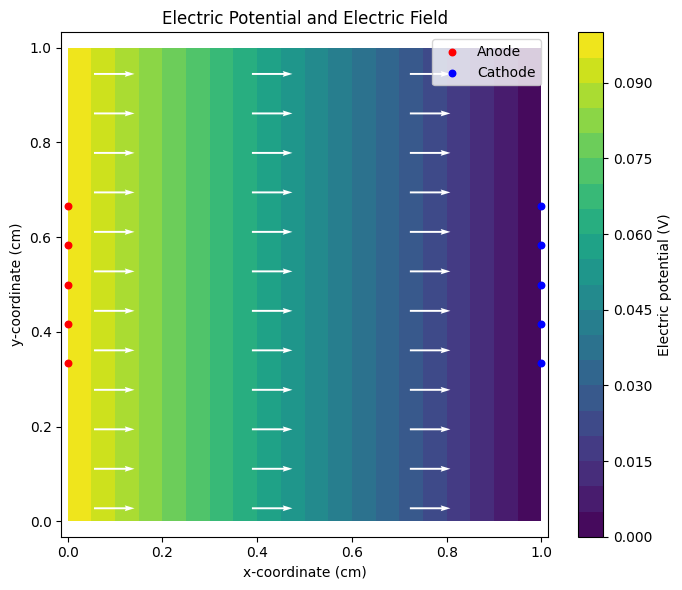

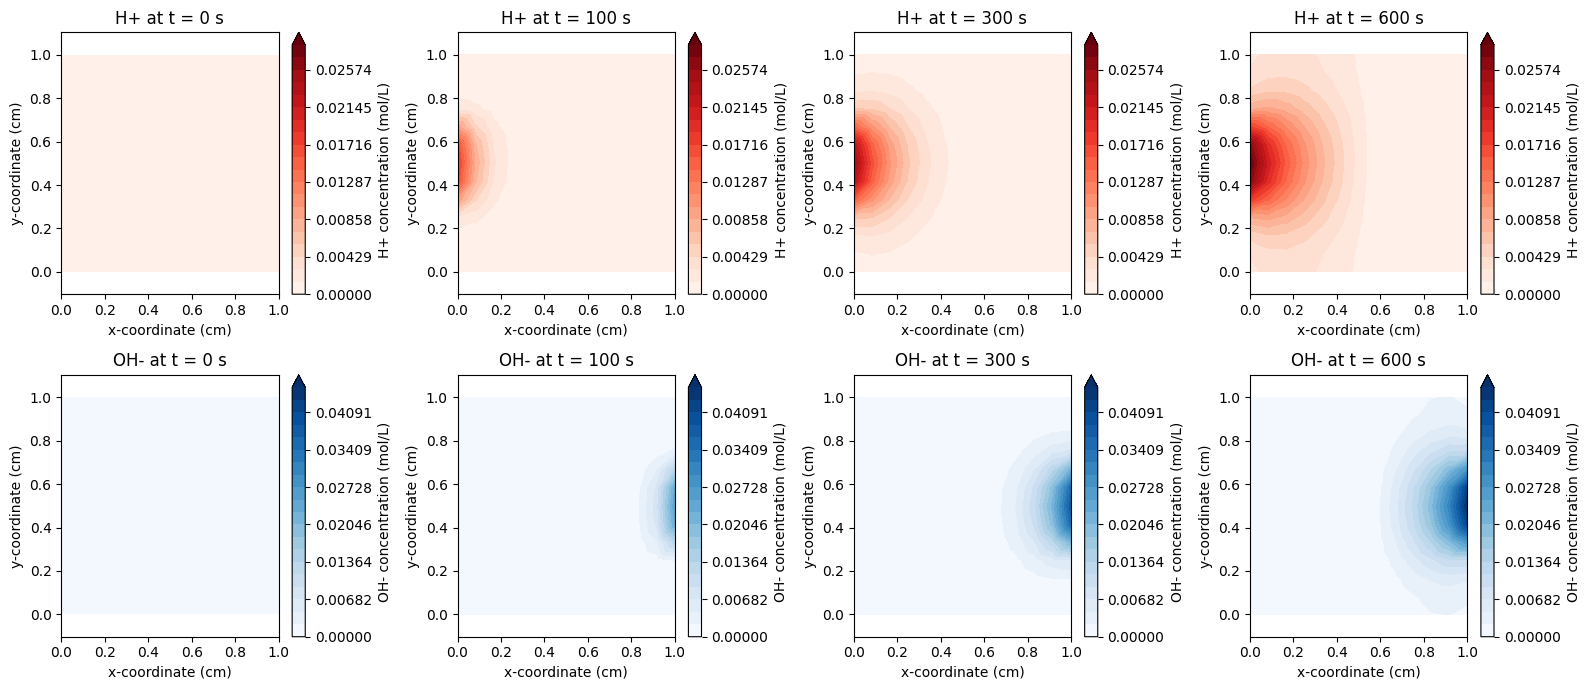

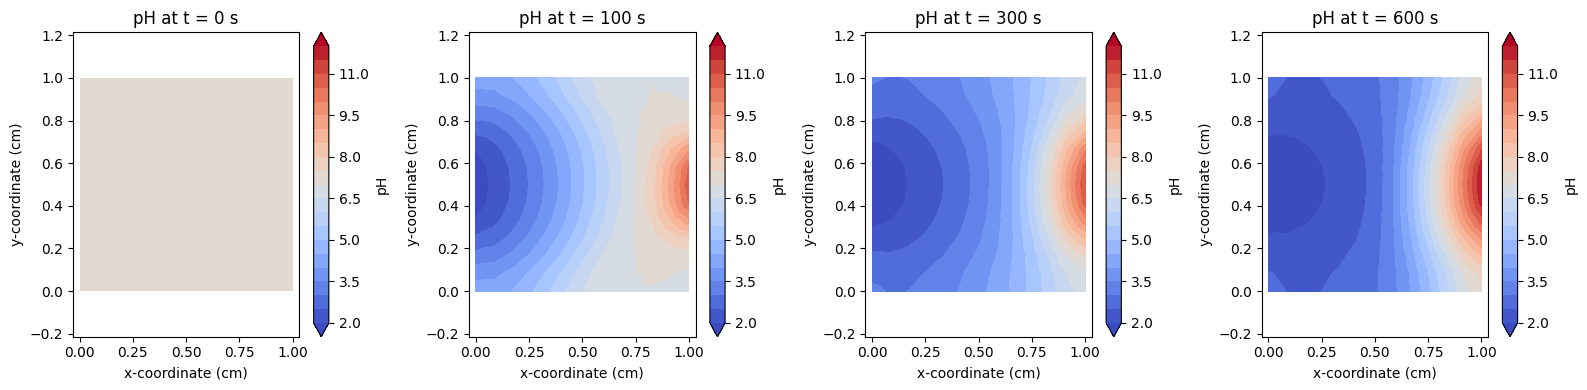

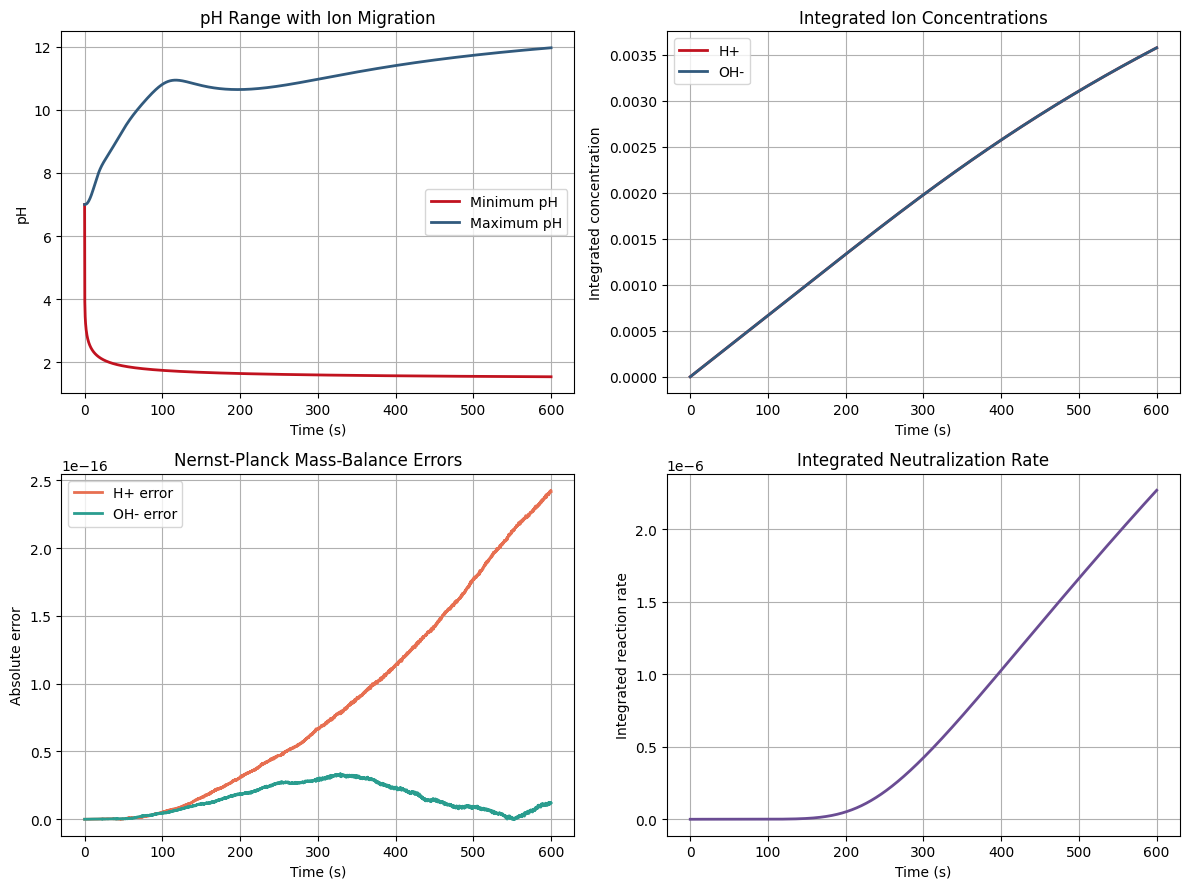

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu_factor, lu_solve
np.set_printoptions(precision=8,suppress=True)
Lx = 1.0
Ly = 1.0
Nx = 12
Ny = 12
x = np.linspace(0.0,Lx,Nx + 1)
y = np.linspace(0.0,Ly,Ny + 1)
X, Y = np.meshgrid(x,y,indexing="xy")
nodes = np.column_stack((X.ravel(),Y.ravel()))
elements = []
for j in range(Ny):
    for i in range(Nx):
        n1 = j * (Nx + 1) + i
        n2 = n1 + 1
        n3 = n1 + (Nx + 1)
        n4 = n3 + 1
        elements.append([n1,n2,n4])
        elements.append([n1,n4,n3])
elements = np.asarray(elements,dtype=int)
number_of_nodes = len(nodes)
number_of_elements = len(elements)
# Physical and effective model parameters
D_hydrogen = 9.31e-5
D_hydroxide = 5.27e-5
reaction_rate_constant = 50.0
initial_neutral_concentration = 1.0e-7
# Electrode concentration fluxes
hydrogen_boundary_flux = 2.0e-5
hydroxide_boundary_flux = 2.0e-5
# Electrochemical constants
faraday_constant = 96485.0
gas_constant = 8.314
absolute_temperature = 298.15
# Ionic charges
hydrogen_charge = 1.0
hydroxide_charge = -1.0
# Electrode potentials
anode_potential = 0.10
cathode_potential = 0.0
electric_coupling = faraday_constant/(gas_constant*absolute_temperature)
print("Number of nodes:",number_of_nodes)
print("Number of elements:",number_of_elements)
print("Hydrogen diffusion coefficient:",D_hydrogen,"cm^2/s")
print("Hydroxide diffusion coefficient:",D_hydroxide,"cm^2/s")
print("Applied potential difference:",anode_potential-cathode_potential,"V")
print("Electric coupling F/(RT):",electric_coupling,"1/V")
# Initialize FEM matrices
global_mass = np.zeros((number_of_nodes,number_of_nodes))
global_stiffness = np.zeros((number_of_nodes,number_of_nodes))
# Store element information
element_areas = np.zeros(number_of_elements)
element_basis_gradients = np.zeros((number_of_elements,3,2))
# Assemble global mass and stiffness matrices
for element_index in range(number_of_elements):
    element = elements[element_index]
    coordinates = nodes[element]
    x1, y1 = coordinates[0]
    x2, y2 = coordinates[1]
    x3, y3 = coordinates[2]
    area = 0.5*((x2-x1)*(y3-y1)-(x3-x1)*(y2-y1))
    if area <= 0.0:
        raise ValueError("A reversed or degenerate element was found.")
    b_coefficients = np.array([y2-y3, y3-y1, y1-y2])
    c_coefficients = np.array([x3-x2, x1-x3, x2-x1])
    basis_gradients = np.column_stack((b_coefficients,c_coefficients))/(2.0*area)
    local_mass = (area/12.0)*np.array([
        [2.0,1.0,1.0],
        [1.0,2.0,1.0],
        [1.0,1.0,2.0]])
    local_stiffness = area*(basis_gradients @ basis_gradients.T)
    element_areas[element_index] = area
    element_basis_gradients[element_index] = basis_gradients
    for local_i in range(3):
        global_i = element[local_i]
        for local_j in range(3):
            global_j = element[local_j]
            global_mass[global_i,global_j] += local_mass[local_i,local_j]
            global_stiffness[global_i,global_j] += local_stiffness[local_i,local_j]
# Construct the lumped mass matrix
lumped_mass_values = np.sum(global_mass,axis=1)
lumped_mass = np.diag(lumped_mass_values)
print("Global mass and stiffness matrices assembled.")
print("Mass matrix shape:",global_mass.shape)
print("Stiffness matrix shape:",global_stiffness.shape)
print("Total mesh area:",element_areas.sum())
# Verify FEM matrices
assert np.all(element_areas > 0.0), "A non-positive element area was found."
assert np.isclose(element_areas.sum(),Lx*Ly), "The mesh area is incorrect."
assert np.max(np.abs(global_mass-global_mass.T)) < 1.0e-12, "The mass matrix is not symmetric."
assert np.max(np.abs(global_stiffness-global_stiffness.T)) < 1.0e-12, "The stiffness matrix is not symmetric."
assert np.all(lumped_mass_values > 0.0), "The lumped mass matrix contains a non-positive entry."
# Identify electric-potential boundary nodes
left_boundary_nodes = np.flatnonzero(np.isclose(nodes[:, 0],0.0))
right_boundary_nodes = np.flatnonzero(np.isclose(nodes[:, 0],Lx))
potential_boundary_nodes = np.concatenate((left_boundary_nodes,right_boundary_nodes))
all_node_indices = np.arange(number_of_nodes)
free_potential_nodes = np.setdiff1d(all_node_indices,potential_boundary_nodes)
# Apply electrode potentials
electric_potential = np.zeros(number_of_nodes)
electric_potential[left_boundary_nodes] = anode_potential
electric_potential[right_boundary_nodes] = cathode_potential
# Construct the potential right-hand side
potential_right_hand_side = -global_stiffness[np.ix_(free_potential_nodes,potential_boundary_nodes)] @ electric_potential[potential_boundary_nodes]
# Solve the Laplace equation
electric_potential[free_potential_nodes] = np.linalg.solve(global_stiffness[np.ix_(free_potential_nodes,free_potential_nodes)],potential_right_hand_side)
# Exact linear potential for verification
exact_potential = anode_potential+(cathode_potential-anode_potential)*nodes[:, 0]/Lx
potential_error = np.max(np.abs(electric_potential-exact_potential))
print("Minimum electric potential:",np.min(electric_potential),"V")
print("Maximum electric potential:",np.max(electric_potential),"V")
print("Maximum potential error:",potential_error)
assert potential_error < 1.0e-12, "The electric-potential solution is incorrect."
# Initialize Nernst-Planck migration matrices
hydrogen_migration = np.zeros((number_of_nodes,number_of_nodes))
hydroxide_migration = np.zeros((number_of_nodes,number_of_nodes))
# Store element electric fields and migration velocities
element_electric_field = np.zeros((number_of_elements,2))
element_hydrogen_velocity = np.zeros((number_of_elements,2))
element_hydroxide_velocity = np.zeros((number_of_elements,2))
# Assemble conservative migration matrices
for element_index in range(number_of_elements):
    element = elements[element_index]
    area = element_areas[element_index]
    basis_gradients = element_basis_gradients[element_index]
    potential_gradient = electric_potential[element] @ basis_gradients
    electric_field = -potential_gradient
    # Ion migration velocities
    hydrogen_velocity = hydrogen_charge*D_hydrogen*electric_coupling*electric_field
    hydroxide_velocity = hydroxide_charge*D_hydroxide*electric_coupling*electric_field
    # Local migration matrices
    local_hydrogen_migration = -(area/3.0)*np.outer(basis_gradients @ hydrogen_velocity,np.ones(3))
    local_hydroxide_migration = -(area/3.0)*np.outer(basis_gradients @ hydroxide_velocity,np.ones(3))
    element_electric_field[element_index] = electric_field
    element_hydrogen_velocity[element_index] = hydrogen_velocity
    element_hydroxide_velocity[element_index] = hydroxide_velocity
    for local_i in range(3):
        global_i = element[local_i]
        for local_j in range(3):
            global_j = element[local_j]
            hydrogen_migration[global_i,global_j] += local_hydrogen_migration[local_i,local_j]
            hydroxide_migration[global_i,global_j] += local_hydroxide_migration[local_i,local_j]
# Check migration-matrix conservation
constant_vector = np.ones(number_of_nodes)
hydrogen_migration_conservation_error = np.max(np.abs(constant_vector @ hydrogen_migration))
hydroxide_migration_conservation_error = np.max(np.abs(constant_vector @ hydroxide_migration))
print("Mean electric field:",np.mean(element_electric_field,axis=0),"V/cm")
print("Mean hydrogen migration velocity:",np.mean(element_hydrogen_velocity,axis=0),"cm/s")
print("Mean hydroxide migration velocity:",np.mean(element_hydroxide_velocity,axis=0),"cm/s")
print("Hydrogen migration conservation error:",hydrogen_migration_conservation_error)
print("Hydroxide migration conservation error:",hydroxide_migration_conservation_error)
assert hydrogen_migration_conservation_error < 1.0e-12, "The hydrogen migration matrix is not conservative."
assert hydroxide_migration_conservation_error < 1.0e-12, "The hydroxide migration matrix is not conservative."
# Construct electrode-flux vectors
electrode_y_minimum = 1.0/3.0
electrode_y_maximum = 2.0/3.0
hydrogen_flux_vector = np.zeros(number_of_nodes)
hydroxide_flux_vector = np.zeros(number_of_nodes)
anode_nodes = []
cathode_nodes = []
for j in range(Ny):
    y_bottom = y[j]
    y_top = y[j + 1]
    edge_midpoint = 0.5*(y_bottom+y_top)
    edge_length = y_top-y_bottom
    if electrode_y_minimum <= edge_midpoint <= electrode_y_maximum:
        left_bottom = j*(Nx + 1)
        left_top = (j + 1)*(Nx + 1)
        right_bottom = j*(Nx + 1) + Nx
        right_top = (j + 1)*(Nx + 1) + Nx
        hydrogen_flux_vector[left_bottom] += hydrogen_boundary_flux*edge_length/2.0
        hydrogen_flux_vector[left_top] += hydrogen_boundary_flux*edge_length/2.0
        hydroxide_flux_vector[right_bottom] += hydroxide_boundary_flux*edge_length/2.0
        hydroxide_flux_vector[right_top] += hydroxide_boundary_flux*edge_length/2.0
        anode_nodes.extend([left_bottom,left_top])
        cathode_nodes.extend([right_bottom,right_top])
anode_nodes = np.unique(np.asarray(anode_nodes,dtype=int))
cathode_nodes = np.unique(np.asarray(cathode_nodes,dtype=int))
hydrogen_injection_rate = np.sum(hydrogen_flux_vector)
hydroxide_injection_rate = np.sum(hydroxide_flux_vector)
print("Number of anode nodes:",len(anode_nodes))
print("Number of cathode nodes:",len(cathode_nodes))
print("Hydrogen injection rate:",hydrogen_injection_rate)
print("Hydroxide injection rate:",hydroxide_injection_rate)
# Time parameters
initial_time = 0.0
final_time = 600.0
time_step = 0.25
number_of_time_steps = int(round((final_time-initial_time)/time_step))
time_values = np.linspace(initial_time,final_time,number_of_time_steps + 1)
# Construct Nernst-Planck system matrices
hydrogen_system_matrix = lumped_mass+time_step*(D_hydrogen*global_stiffness+hydrogen_migration)
hydroxide_system_matrix = lumped_mass+time_step*(D_hydroxide*global_stiffness+hydroxide_migration)
# Factorize both matrices once
hydrogen_lu, hydrogen_pivots = lu_factor(hydrogen_system_matrix)
hydroxide_lu, hydroxide_pivots = lu_factor(hydroxide_system_matrix)
print("Initial time:",initial_time)
print("Final time:",final_time)
print("Time-step size:",time_step)
print("Number of time steps:",number_of_time_steps)
# Initial neutral concentrations
hydrogen_concentration = initial_neutral_concentration*np.ones(number_of_nodes)
hydroxide_concentration = initial_neutral_concentration*np.ones(number_of_nodes)
# Function for calculating pH
def calculate_pH(hydrogen_values):
    safe_hydrogen = np.maximum(hydrogen_values,1.0e-14)
    return -np.log10(safe_hydrogen)
pH_values = calculate_pH(hydrogen_concentration)
# Diagnostic arrays
total_hydrogen = np.zeros(number_of_time_steps + 1)
total_hydroxide = np.zeros(number_of_time_steps + 1)
minimum_pH = np.zeros(number_of_time_steps + 1)
maximum_pH = np.zeros(number_of_time_steps + 1)
integrated_reaction_rate = np.zeros(number_of_time_steps + 1)
cumulative_reaction = np.zeros(number_of_time_steps + 1)
hydrogen_balance_error = np.zeros(number_of_time_steps + 1)
hydroxide_balance_error = np.zeros(number_of_time_steps + 1)
initial_total_hydrogen = constant_vector @ lumped_mass @ hydrogen_concentration
initial_total_hydroxide = constant_vector @ lumped_mass @ hydroxide_concentration
# Store diagnostic values
def store_diagnostics(step):
    reaction_term = reaction_rate_constant*hydrogen_concentration*hydroxide_concentration
    total_hydrogen[step] = constant_vector @ lumped_mass @ hydrogen_concentration
    total_hydroxide[step] = constant_vector @ lumped_mass @ hydroxide_concentration
    minimum_pH[step] = np.min(pH_values)
    maximum_pH[step] = np.max(pH_values)
    integrated_reaction_rate[step] = constant_vector @ lumped_mass @ reaction_term
    injected_hydrogen = time_values[step]*hydrogen_injection_rate
    injected_hydroxide = time_values[step]*hydroxide_injection_rate
    hydrogen_balance_error[step] = total_hydrogen[step]-initial_total_hydrogen-injected_hydrogen+cumulative_reaction[step]
    hydroxide_balance_error[step] = total_hydroxide[step]-initial_total_hydroxide-injected_hydroxide+cumulative_reaction[step]
store_diagnostics(0)
# Selected output times
selected_times = [0.0,100.0,300.0,600.0]
selected_steps = [int(round(time/time_step)) for time in selected_times]
# Store initial solutions
hydrogen_snapshots = {0: hydrogen_concentration.copy()}
hydroxide_snapshots = {0: hydroxide_concentration.copy()}
pH_snapshots = {0: pH_values.copy()}
# IMEX Euler time integration
for time_step_index in range(1,number_of_time_steps + 1):
    reaction_term = reaction_rate_constant*hydrogen_concentration*hydroxide_concentration
    current_reaction_integral = constant_vector @ lumped_mass @ reaction_term
    hydrogen_right_hand_side = lumped_mass @ hydrogen_concentration-time_step*(lumped_mass @ reaction_term)+time_step*hydrogen_flux_vector
    hydroxide_right_hand_side = lumped_mass @ hydroxide_concentration-time_step*(lumped_mass @ reaction_term)+time_step*hydroxide_flux_vector
    # Solve the implicit transport systems
    hydrogen_concentration = lu_solve((hydrogen_lu,hydrogen_pivots),hydrogen_right_hand_side)
    hydroxide_concentration = lu_solve((hydroxide_lu,hydroxide_pivots),hydroxide_right_hand_side)
    # Calculate pH
    pH_values = calculate_pH(hydrogen_concentration)
    # Update cumulative neutralization
    cumulative_reaction[time_step_index] = cumulative_reaction[time_step_index-1]+time_step*current_reaction_integral
    # Store numerical diagnostics
    store_diagnostics(time_step_index)
    # Store selected solutions
    if time_step_index in selected_steps:
        hydrogen_snapshots[time_step_index] = hydrogen_concentration.copy()
        hydroxide_snapshots[time_step_index] = hydroxide_concentration.copy()
        pH_snapshots[time_step_index] = pH_values.copy()
print("Nernst-Planck ion-transport simulation completed.")
# Final numerical verification
all_values_are_finite = np.all(np.isfinite(hydrogen_concentration)) and np.all(np.isfinite(hydroxide_concentration)) and np.all(np.isfinite(pH_values))
minimum_ion_concentration = min(np.min(hydrogen_concentration),np.min(hydroxide_concentration))
maximum_hydrogen_balance_error = np.max(np.abs(hydrogen_balance_error))
maximum_hydroxide_balance_error = np.max(np.abs(hydroxide_balance_error))
print("Initial total hydrogen concentration:",total_hydrogen[0])
print("Final total hydrogen concentration:",total_hydrogen[-1])
print("Initial total hydroxide concentration:",total_hydroxide[0])
print("Final total hydroxide concentration:",total_hydroxide[-1])
print("Final minimum pH:",minimum_pH[-1])
print("Final maximum pH:",maximum_pH[-1])
print("Minimum final ion concentration:",minimum_ion_concentration)
print("Maximum hydrogen balance error:",maximum_hydrogen_balance_error)
print("Maximum hydroxide balance error:",maximum_hydroxide_balance_error)
assert all_values_are_finite, "The solution contains NaN or infinite values."
assert minimum_ion_concentration >= -1.0e-12, "A negative ion concentration was produced."
assert maximum_hydrogen_balance_error < 1.0e-10, "The hydrogen mass balance failed."
assert maximum_hydroxide_balance_error < 1.0e-10, "The hydroxide mass balance failed."
assert minimum_pH[-1] < 7.0, "An acidic region was not produced."
assert maximum_pH[-1] > 7.0, "A basic region was not produced."
print("All electric-potential, migration, and mass-balance checks passed successfully.")
# Element centres for electric-field arrows
element_centres = np.mean(nodes[elements],axis=1)
# Plot only some arrows to avoid overcrowding
plot_elements = np.arange(0,number_of_elements,8)
potential_levels = np.linspace(cathode_potential,anode_potential,21)
# Plot electric potential and electric field
plt.figure(figsize=(7,6))
potential_plot = plt.tricontourf(nodes[:, 0],nodes[:, 1],elements,electric_potential,levels=potential_levels,cmap="viridis")
plt.colorbar(potential_plot,label="Electric potential (V)")
plt.quiver(element_centres[plot_elements,0],element_centres[plot_elements,1],element_electric_field[plot_elements,0],element_electric_field[plot_elements,1],color="white",scale=1.2,width=0.004)
plt.scatter(nodes[anode_nodes,0],nodes[anode_nodes,1],color="red",s=22,label="Anode")
plt.scatter(nodes[cathode_nodes,0],nodes[cathode_nodes,1],color="blue",s=22,label="Cathode")
plt.title("Electric Potential and Electric Field")
plt.xlabel("x-coordinate (cm)")
plt.ylabel("y-coordinate (cm)")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.savefig("electric_potential_and_field.png",dpi=300,bbox_inches="tight")
plt.show()
# Common concentration and pH levels
hydrogen_maximum = max(np.max(hydrogen_snapshots[step]) for step in selected_steps)
hydroxide_maximum = max(np.max(hydroxide_snapshots[step]) for step in selected_steps)
hydrogen_levels = np.linspace(0.0,hydrogen_maximum,21)
hydroxide_levels = np.linspace(0.0,hydroxide_maximum,21)
pH_levels = np.linspace(2.0,12.0,21)
# Plot ion-concentration evolution
plt.figure(figsize=(16,7))
for plot_index, step in enumerate(selected_steps):
    plt.subplot(2,4,plot_index + 1)
    hydrogen_plot = plt.tricontourf(nodes[:, 0],nodes[:, 1],elements,hydrogen_snapshots[step],levels=hydrogen_levels,cmap="Reds",extend="max")
    plt.colorbar(hydrogen_plot,label="H+ concentration (mol/L)")
    plt.title(f"H+ at t = {time_values[step]:.0f} s")
    plt.xlabel("x-coordinate (cm)")
    plt.ylabel("y-coordinate (cm)")
    plt.axis("equal")
    plt.subplot(2,4,plot_index + 5)
    hydroxide_plot = plt.tricontourf(nodes[:, 0],nodes[:, 1],elements,hydroxide_snapshots[step],levels=hydroxide_levels,cmap="Blues",extend="max")
    plt.colorbar(hydroxide_plot,label="OH- concentration (mol/L)")
    plt.title(f"OH- at t = {time_values[step]:.0f} s")
    plt.xlabel("x-coordinate (cm)")
    plt.ylabel("y-coordinate (cm)")
    plt.axis("equal")
plt.tight_layout()
plt.savefig("nernst_planck_ion_evolution.png",dpi=300,bbox_inches="tight")
plt.show()
# Plot pH evolution
plt.figure(figsize=(16,4))
for plot_index, step in enumerate(selected_steps,start=1):
    plt.subplot(1,4,plot_index)
    pH_plot = plt.tricontourf(nodes[:, 0],nodes[:, 1],elements,pH_snapshots[step],levels=pH_levels,cmap="coolwarm",extend="both")
    plt.colorbar(pH_plot,label="pH")
    plt.title(f"pH at t = {time_values[step]:.0f} s")
    plt.xlabel("x-coordinate (cm)")
    plt.ylabel("y-coordinate (cm)")
    plt.axis("equal")
plt.tight_layout()
plt.savefig("nernst_planck_pH_evolution.png",dpi=300,bbox_inches="tight")
plt.show()
# Plot numerical-verification graphs
plt.figure(figsize=(12,9))
# pH range
plt.subplot(2,2,1)
plt.plot(time_values,minimum_pH,color="#C1121F",linewidth=2,label="Minimum pH")
plt.plot(time_values,maximum_pH,color="#315A7D",linewidth=2,label="Maximum pH")
plt.title("pH Range with Ion Migration")
plt.xlabel("Time (s)")
plt.ylabel("pH")
plt.grid(True)
plt.legend()
# Integrated ion concentrations
plt.subplot(2,2,2)
plt.plot(time_values,total_hydrogen,color="#C1121F",linewidth=2,label="H+")
plt.plot(time_values,total_hydroxide,color="#315A7D",linewidth=2,label="OH-")
plt.title("Integrated Ion Concentrations")
plt.xlabel("Time (s)")
plt.ylabel("Integrated concentration")
plt.grid(True)
plt.legend()
# Mass-balance errors
plt.subplot(2,2,3)
plt.plot(time_values,np.abs(hydrogen_balance_error),color="#E76F51",linewidth=2,label="H+ error")
plt.plot(time_values,np.abs(hydroxide_balance_error),color="#2A9D8F",linewidth=2,label="OH- error")
plt.title("Nernst-Planck Mass-Balance Errors")
plt.xlabel("Time (s)")
plt.ylabel("Absolute error")
plt.grid(True)
plt.legend()
# Integrated reaction rate
plt.subplot(2,2,4)
plt.plot(time_values,integrated_reaction_rate,color="#6A4C93",linewidth=2)
plt.title("Integrated Neutralization Rate")
plt.xlabel("Time (s)")
plt.ylabel("Integrated reaction rate")
plt.grid(True)

plt.tight_layout()

plt.savefig("nernst_planck_verification_graphs.png",dpi=300,bbox_inches="tight")

plt.show()

## **Results and Interpretation**

In part 7 electric potential and charge dependent Nernst-Planck migration were successfully integrated in the finite element ion transport model.

The calculated electric potential decreased smoothly from $0.10\ \mathrm{V}$ at the anode to $0\ \mathrm{V}$ at the cathode. The maximum error relative to the exact linear potential was approximately $3.68\times10^{-16}$. This confirms that the FEM solution of Laplace’s equation and the implementation of the potential boundary conditions were numerically correct.

The mean electric field was

$$
\mathbf{E}\approx(0.10,0)\ \mathrm{V/cm},
$$

and therefore pointed from the anode towards the cathode. The mean hydrogen-ion migration velocity was approximately

$$
\mathbf{v}_{\mathrm{H}^{+}}\approx(3.62\times10^{-4},0)\ \mathrm{cm/s},
$$

whereas the mean hydroxide-ion migration velocity was

$$
\mathbf{v}_{\mathrm{OH}^{-}}\approx(-2.05\times10^{-4},0)\ \mathrm{cm/s}.
$$

The opposite signs confirm the expected charge-dependent behaviour: positively charged hydrogen ions migrated in the electric-field direction, while negatively charged hydroxide ions migrated against it. The larger hydrogen migration speed resulted from its larger diffusion coefficient.

The potential and electric-field figure shows a nearly uniform horizontal field. The ion-concentration plots demonstrate that this field drives the two ionic species towards one another, increasing their overlap in the interior of the domain. Consequently, electric migration affects both the shape of the concentration distributions and the location of the neutralization region.

After $600\ \mathrm{s}$, the integrated hydrogen and hydroxide concentrations were approximately equal:

$$
C_{\mathrm{H}^{+}}\approx0.00357522,
\qquad
C_{\mathrm{OH}^{-}}\approx0.00357522.
$$

Their equality is consistent with the equal electrode injection rates and the one-to-one neutralization reaction. Compared with the model without electric migration, the smaller remaining integrated concentrations indicate increased interaction and neutralization caused by the movement of the oppositely charged ions towards the central region.

The final pH ranged from approximately $1.544$ to $11.964$. Within the current pH formulation, these values indicate the presence of acidic and basic regions together with a transition region where ionic migration and neutralization interact. The pH range is less extreme than in the model without migration, which is consistent with stronger redistribution and mixing of the two ionic species.

The migration-conservation errors were extremely small:

$$
E_{B_{\mathrm{H}^{+}}}\approx4.24\times10^{-21},
$$

and

$$
E_{B_{\mathrm{OH}^{-}}}\approx2.12\times10^{-21}.
$$

These results confirm that the assembled migration matrices redistribute ions without introducing artificial numerical sources or losses.

The maximum hydrogen and hydroxide mass-balance errors were approximately

$$
E_{\mathrm{H}^{+}}^{\max}\approx2.43\times10^{-16},
$$

and

$$
E_{\mathrm{OH}^{-}}^{\max}\approx3.37\times10^{-17}.
$$

These errors are close to machine precision and verify that electrode injection, diffusion, electric migration and neutralization were combined consistently.

The minimum final ion concentration was approximately $1.48\times10^{-15}$ and remained non-negative. Therefore, the mass-lumped IMEX finite element formulation maintained concentration positivity throughout the simulation.

All electric-potential, migration, positivity and mass-balance checks passed successfully. Part 7 therefore shows a numerically consistent FEM implementation of Nernst–Planck transport for oppositely charged ionic species. The addition of electric migration produces physically meaningful directional transport and provides a stronger electrochemical extension of the previous reaction–diffusion framework.
